# 4 - How do CAD–USD exchange rate fluctuations influence profitability in export-heavy vs. import-heavy industries?**

**Avaialble dataset**
- Revenue
- Expenses
- TradeExchange  --> Import , export , GDP and Exchange rate

# Revenue #


In [3]:
import pandas as pd
import numpy as np


In [4]:
# Revenue.columns
# Calcualate yearly revenue 
# 'Year', 'NAICS', 'Description_English','Total revenue',

import pandas as pd

Revenue = pd.read_csv("../RawData/Revenue.csv")

Revenue_orig=Revenue.copy()

# Revenue.rename(columns={"Whole industry Total revenue":"Total Revenue"})
# Revenue.head()

# Group by "Year", "NAICS", "Description_English
Revenue_grouped = Revenue.groupby(
    ["Year", "NAICS", "Description_English"], as_index=False
)["Whole industry Total revenue"].sum()

# Cast from long float to 2 place decimal 
Revenue_grouped["Whole industry Total revenue"] = Revenue_grouped["Whole industry Total revenue"].round(2)

# Group by "Year", "NAICS", "Description_English , "Province"

Revenue_Prov_grouped = Revenue.groupby(
    ["Year", "NAICS", "Description_English","Province","Province_Description"], as_index=False
)["Whole industry Total revenue"].sum()

Revenue_Prov_grouped["Whole industry Total revenue"] = Revenue_Prov_grouped["Whole industry Total revenue"].round(2)

Revenue_grouped =Revenue_grouped .rename(columns = {"Whole industry Total revenue" : "Total Revenue"})

Revenue_Prov_grouped =Revenue_Prov_grouped .rename(columns = {"Whole industry Total revenue" : "Total Revenue"})

# print(Revenue_grouped.head())
# print(Revenue_Prov_grouped.head())

# print(len(Revenue_grouped))
# print(len(Revenue_Prov_grouped))

In [5]:
naics = Revenue_grouped['NAICS'].unique()
print(naics.shape)

(2108,)


# Expenses

In [6]:
# Expenses.columns
# Calcualate yearly expenses 
# 'Year', 'NAICS', 'Description_English','Total expenses'
import pandas as pd

Expenses = pd.read_csv("../RawData/Expenses.csv")

Expenses_orig=Expenses.copy()

Expenses_grouped = Expenses.groupby(
    ["Year", "NAICS", "Description_English"], as_index=False
)[['Total expenses','Net Profit/Loss']].sum()

Expenses_grouped

,Year,NAICS,Description_English,Total expenses,Net Profit/Loss
0,2013,0,Total,8914.2,560.2
1,2013,11,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9
2,2013,21,"Mining, Quarrying, and Oil and Gas Extraction",28091.1,-4213.4
3,2013,22,Utilities,23985.3,2029.1
4,2013,23,Construction,29126.5,3070.3
...,...,...,...,...,...
20161,2023,813920,Professional organizations,8495.9,1363.8
20162,2023,813930,Labour organizations,5391.8,385.3
20163,2023,813940,Political organizations,1249.3,37.7
20164,2023,813990,Other membership organizations,6911.2,684.3


In [7]:
print("Revenue_Prov_grouped : " ,Revenue_Prov_grouped.columns)
print("Revenue_grouped: ", Revenue_grouped.columns)
print("Expenses_grouped : ", Expenses_grouped.columns)


Revenue_Prov_grouped :  Index(['Year', 'NAICS', 'Description_English', 'Province',
       'Province_Description', 'Total Revenue'],
      dtype='object')
Revenue_grouped:  Index(['Year', 'NAICS', 'Description_English', 'Total Revenue'], dtype='object')
Expenses_grouped :  Index(['Year', 'NAICS', 'Description_English', 'Total expenses',
       'Net Profit/Loss'],
      dtype='object')


In [8]:
print("Revenue_grouped :" ,len(Revenue_grouped))
print("Revenue_Prov_grouped :",len(Revenue_Prov_grouped))
print("Expenses_grouped : ",len(Expenses_grouped))

Revenue_grouped : 20862
Revenue_Prov_grouped : 283280
Expenses_grouped :  20166


In [9]:
# validating  key to join 
print(Revenue_Prov_grouped[
    (Revenue_Prov_grouped["Year"] == 2013 ) &
    (Revenue_Prov_grouped["Province"]  == 11 )&
    (Revenue_Prov_grouped["NAICS"] == 11)
])


   Year  NAICS                         Description_English  Province  \
2  2013     11  Agriculture, Forestry, Fishing and Hunting        11   

   Province_Description  Total Revenue  
2  Prince Edward Island         1191.9  


# Trade data 

In [10]:
import pandas as pd

# Load Trade import - Export , GDP and Cad - US exchange rate data  ..File located in Src folder

tradeExposure = pd.read_csv("../src/TradeExposurebyIndustry.csv")
gdp=pd.read_csv("../Src/TradetoGDP.csv") 
ex= pd.read_csv("../Src/Exchange_Rate.csv")


# print(tradeExposure.head())
# print(gdp.head())
# print(ex.head())
# print("\n\n")

# Merge them and make one dataset

fx = pd.merge(tradeExposure, gdp,  on=["Province", "REF_DATE", "industry"] , how= "left")

fx = fx.rename(columns={"REF_DATE": 'Year'})


# TradeExchange = fx.merge(ex , left_on= ["REF_DATE"] , right_on = ["Year"], how = "left")
TradeExchange = fx.merge(
    ex,
    left_on="Year",   # key in Fx
    right_on="Year",      # key in Exchange
    how="left"
    )

# TradeExchange[["Year", "Incorporation Status","Province","Naics code"]] = TradeExchange[["Year", "Incorporation Status","Province","Naics code"]].astype(int)


print("tradeExposure" , len(tradeExposure))
print("gdp",len(gdp))
print("TradeExchange" , len(TradeExchange))
TradeExchange.info()
TradeExchange.head()


tradeExposure 2029
gdp 3003
TradeExchange 2029
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2029 entries, 0 to 2028
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Province               2029 non-null   object 
 1   industry               2029 non-null   int64  
 2   Year                   2029 non-null   int64  
 3   total_trade            2029 non-null   float64
 4   Value of exports       2029 non-null   float64
 5   Value of imports       2029 non-null   float64
 6   GDP                    2029 non-null   int64  
 7   CAD_USD_Exchange_Rate  2029 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 142.7+ KB


,Province,industry,Year,total_trade,Value of exports,Value of imports,GDP,CAD_USD_Exchange_Rate
0,Alberta,0,2013,139364164.0,92750112.0,46614052.0,310713,1.030137
1,Alberta,0,2014,153658120.0,103631865.0,50026255.0,328652,1.104747
2,Alberta,0,2015,120889390.0,79154756.0,41734634.0,317182,1.278786
3,Alberta,0,2016,104104281.0,64621025.0,39483256.0,306203,1.325615
4,Alberta,0,2017,125464737.0,85402212.0,40062525.0,319212,1.297936


In [11]:
# Rename by reassigning dataframe
# revenue = Revenue_Prov_grouped
# expenses= Expenses_grouped


# Analysis before merge 
# NAICS  /  Industry  data availability in revenue , expenses  , trade
Based on the analysis above, I conclude that I will proceed with industry-level (NAICS) data that is consistently available across all datasets. These include Revenue, Expenses, and Trade.

The next step is to merge the datasets using only the common NAICS codes and then perform further analysis on those industries


In [12]:
import numpy as np

ind = TradeExchange["industry"].unique()
revNaics = Revenue_grouped["NAICS"].unique()
expNaics= Expenses_grouped["NAICS"].unique()


# Industries in TradeExchange but not in Revenue_grouped
missing_in_revenue = np.setdiff1d(ind, revNaics)

# Industries in Revenue_grouped but not in TradeExchange
missing_in_trade_rev = np.setdiff1d(revNaics, ind)

# Industries in Expenses_grouped but not in TradeExchange
missing_in_trade_Exp = np.setdiff1d(expNaics, ind)

print ("\n ind " ,  ind )
print("Missing in Expenses_grouped:", missing_in_revenue)
print("Missing in Trade Rev:", missing_in_trade_rev)
print("Missing in Trade Exp:", missing_in_trade_Exp)

# Missing in Expenses_grouped: [31 44 48 52 91]


 ind  [ 0 11 21 22 23 31 41 44 48 51 52 53 54 55 56 61 62 71 72 81 91]
Missing in Expenses_grouped: [31 44 48 52 91]
Missing in Trade Rev: [   111    112    113 ... 813940 813990 814110]
Missing in Trade Exp: [   111    112    113 ... 813940 813990 814110]


# ****************************************** ***************************** ******** #


In [13]:
# print(TradeExchange.info())
# print(revenue.info())
# print(expenses.info())
# print(Exrt.info())

# Analysis on Dataset
- I initially planned to prepare the data at the province level, but after reviewing the files- Revenue  , Expenses  and Trade, I found that province-level information is only available in the Revenue and Trade CSVs. The Expenses data does not include any province-level details.

- I will proceed with analyzing yearly revenue and expenses at the industry (NAICS) level and add province level for Revenue and tread column

- I am also assuming that the data available in the Expenses, GDP, and Trade files represents all incorporation statuses (1, 2, and 3), since no specific status is identified in those datasets.

- The Revenue CSV includes an incorporation status column, which clearly indicates the status for each record.

In [15]:
revenue = Revenue_Prov_grouped
expenses= Expenses_grouped
print("Revenue : " ,revenue.columns)
print("\nExpenses : ", expenses.columns)
print("\nTradeExchange: ", TradeExchange.columns)

print("\n\nRevenue count : " ,revenue.shape)
print("\nExpenses count: ", expenses.shape)
print("\nTradeExchange count : ", TradeExchange.shape)



Revenue :  Index(['Year', 'NAICS', 'Description_English', 'Province',
       'Province_Description', 'Total Revenue'],
      dtype='object')

Expenses :  Index(['Year', 'NAICS', 'Description_English', 'Total expenses',
       'Net Profit/Loss'],
      dtype='object')

TradeExchange:  Index(['Province', 'industry', 'Year', 'total_trade', 'Value of exports',
       'Value of imports', 'GDP', 'CAD_USD_Exchange_Rate'],
      dtype='object')


Revenue count :  (283280, 6)

Expenses count:  (20166, 5)

TradeExchange count :  (2029, 8)


# Merge Data Revenue , Trade and Exenses  for Annual Data Analysis 

datasets
revenue = pd.read_csv("revenue.csv")   # columns: year, revenue
expenses = pd.read_csv("expenses.csv") # columns: year, expenses
trade = pd.read_csv("trade.csv")       # columns: year, imports, exports ,CAD_USD_Exchange_Rate


# Structure
    -revenue: year, industry, revenue     --->  industry level 
    -trade :  year, industry, imports, exports  -----> Trade industry level and Exchange rate is national leval
    -expenses:year, industry, expenses  ---> industry-level expenses (broadcast across provinces)



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Merge Data Revenue , Trade and Exenses  for Annual Data Analysis 

revenue_anu = Revenue_grouped
expenses_anu= Expenses_grouped

# # Merge revenue , trade  and exchange rate (national-level) on Year
# df = (revenue_anu
#       .merge(expenses, on=['Year', 'NAICS'])
#       .merge(TradeExchange ,  left_on=['Year', 'NAICS'] ,right_on['Year', 'industry'])
#      )

df = (revenue_anu
      .merge(expenses, on=['Year', 'NAICS'])
      .merge(TradeExchange, 
             left_on=['Year', 'NAICS'], 
             right_on=['Year', 'industry'])
     )


# Derived metrics
df["profit"] = df["Total Revenue"] - df["Total expenses"]

df["rev_usd"] = df["Total Revenue"] / df["CAD_USD_Exchange_Rate"]

df["exp_usd"] = df["Total expenses"] / df["CAD_USD_Exchange_Rate"]

# Growth rates (year-over-year % change)

df["rev_growth"] = df["Total Revenue"].pct_change()

df["exp_growth"] = df["Total expenses"].pct_change()

df["fx_change"] =  df["CAD_USD_Exchange_Rate"].pct_change()

df["export_growth"] = df["Value of exports"].pct_change()

df["import_growth"] = df["Value of imports"].pct_change()

# Data set is ready 
df

,Year,NAICS,Description_English_x,Total Revenue,Description_English_y,Total expenses,Net Profit/Loss,Province,industry,total_trade,...,GDP,CAD_USD_Exchange_Rate,profit,rev_usd,exp_usd,rev_growth,exp_growth,fx_change,export_growth,import_growth
0,2013,11,"Agriculture, Forestry, Fishing and Hunting",827510.7,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9,Alberta,11,135239.0,...,6022,1.030137,798121.9,803301.315843,28529.010816,NaN,NaN,NaN,NaN,NaN
1,2013,11,"Agriculture, Forestry, Fishing and Hunting",827510.7,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9,British Columbia,11,566255.0,...,5943,1.030137,798121.9,803301.315843,28529.010816,0.0,0.0,0.0,4.474930,1.756894
2,2013,11,"Agriculture, Forestry, Fishing and Hunting",827510.7,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9,Manitoba,11,62089.0,...,2619,1.030137,798121.9,803301.315843,28529.010816,0.0,0.0,0.0,-0.890176,-0.890739
3,2013,11,"Agriculture, Forestry, Fishing and Hunting",827510.7,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9,New Brunswick,11,252441.0,...,1143,1.030137,798121.9,803301.315843,28529.010816,0.0,0.0,0.0,4.637670,-0.418609
4,2013,11,"Agriculture, Forestry, Fishing and Hunting",827510.7,"Agriculture, Forestry, Fishing and Hunting",29388.8,-1876.9,Newfoundland and Labrador,11,215104.0,...,902,1.030137,798121.9,803301.315843,28529.010816,0.0,0.0,0.0,-0.129256,-0.548744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439,2023,81,Other services (except public administration),426996.6,Other services (except public administration),25065.0,1932.2,Newfoundland and Labrador,81,22663.0,...,524,1.349909,401931.6,316315.183881,18567.923220,0.0,0.0,0.0,-0.870606,1.368075
1440,2023,81,Other services (except public administration),426996.6,Other services (except public administration),25065.0,1932.2,Nova Scotia,81,38258.0,...,916,1.349909,401931.6,316315.183881,18567.923220,0.0,0.0,0.0,0.566474,0.691958
1441,2023,81,Other services (except public administration),426996.6,Other services (except public administration),25065.0,1932.2,Ontario,81,1604116.0,...,16193,1.349909,401931.6,316315.183881,18567.923220,0.0,0.0,0.0,205.252768,36.137193
1442,2023,81,Other services (except public administration),426996.6,Other services (except public administration),25065.0,1932.2,Quebec,81,446798.0,...,9582,1.349909,401931.6,316315.183881,18567.923220,0.0,0.0,0.0,-0.506561,-0.756272


#  Visualization

In [17]:
#  Correlation matrix
print(df[["rev_growth","exp_growth","fx_change","export_growth","import_growth"]].corr())


               rev_growth  exp_growth  fx_change  export_growth  import_growth
rev_growth       1.000000   -0.155345   0.160879       0.134764      -0.004235
exp_growth      -0.155345    1.000000   0.076384       0.006357       0.049138
fx_change        0.160879    0.076384   1.000000      -0.002383      -0.001916
export_growth    0.134764    0.006357  -0.002383       1.000000       0.021375
import_growth   -0.004235    0.049138  -0.001916       0.021375       1.000000


C:\Users\dimpa\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


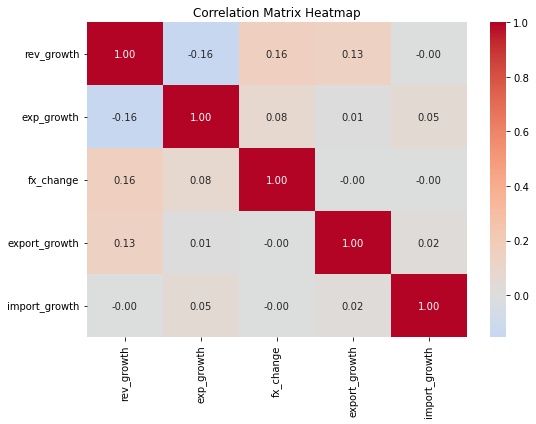

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df[["rev_growth","exp_growth","fx_change","export_growth","import_growth"]].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

# Figure 1: Interrelationships Between Growth Metrics and Exchange Rate Changes

**Correlation measures how two variables move in relation to each other . It is express as number between  -1 and +1 as we see in oure correlation table above figure we are genere correlation matrix for "rev_growth", "exp_growth", "fx_change", "export_growth", "import_growth"  columns . so +1 is perfect correlation . -1 is perfect nagative correlation means one varible going up then other one going opposit of that which is down. 0 represent no correlation meaning both varibale move indipendetly.based on this understanding I have few observation on my corrlation matrix.**
based on observation 
- Revenue vs FX Change (0.16): Slight positive correlation- revenue tends to grow when CAD weakens.
- Revenue vs Export Growth (0.13): Mild positive link -revenue grows modestly with exports
- Expenses vs FX Change (0.08): Very weak positive correlation- expenses rise slightly when CAD weakens, but not consistently.
- Expenses vs Imports (0.05): Weak link- import growth only slightly affects expenses.
- FX vs Trade Volumes (~0.05-0.10): Almost no correlation- exchange rate changes don’t strongly drive import/export volumes in this dataset.
- Revenue vs Expenses ( -0.16): Slight negative correlation - when revenue grows, expenses sometimes shrink, suggesting efficiency gains or cost controls.


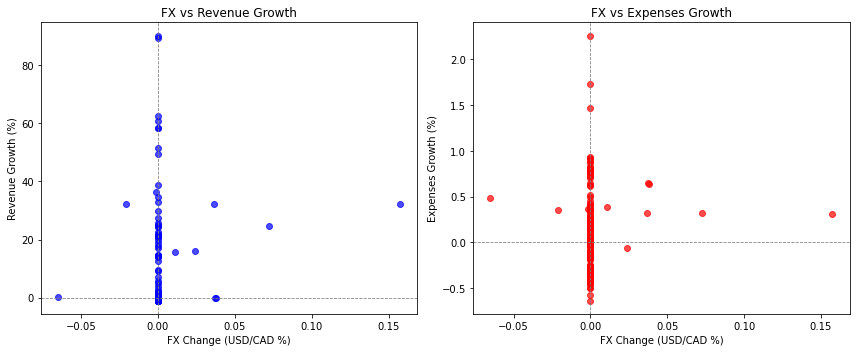

In [85]:
#Scatter plots: FX vs Revenue/Expenses growth

plt.figure(figsize=(12,5))

# FX vs Revenue Growth
plt.subplot(1,2,1)
plt.scatter(df["fx_change"], df["rev_growth"], color="blue", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("FX Change (USD/CAD %)")
plt.ylabel("Revenue Growth (%)")
plt.title("FX vs Revenue Growth")

# FX vs Expenses Growth
plt.subplot(1,2,2)
plt.scatter(df["fx_change"], df["exp_growth"], color="red", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("FX Change (USD/CAD %)")
plt.ylabel("Expenses Growth (%)")
plt.title("FX vs Expenses Growth")

plt.tight_layout()
plt.show()


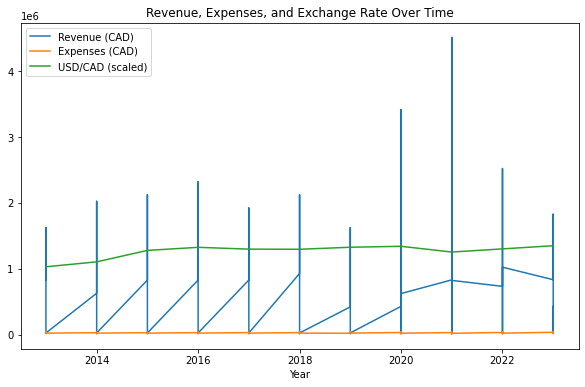

In [84]:
#  Visualization
plt.figure(figsize=(10,6))
plt.plot(df["Year"], df["Total Revenue"], label="Revenue (CAD)")
plt.plot(df["Year"], df["Total expenses"], label="Expenses (CAD)")
plt.plot(df["Year"], df["CAD_USD_Exchange_Rate"]*1e6, label="USD/CAD (scaled)")  # scaled for visibility

plt.legend()
plt.title("Revenue, Expenses, and Exchange Rate Over Time")
plt.xlabel("Year")
plt.show()


# Conclusion : 
    
**This chart illustrates the interplay between financial performance and currency fluctuations over time, offering a visual diagnosis of revenue, expenses, and the USD/CAD exchange rate from 2013 to 2023. By plotting total revenue and total expenses in Canadian dollars alongside a scaled exchange rate, the visualization enables quick assessment of profitability trends and potential foreign exchange sensitivity. If revenue consistently exceeds expenses, it signals operational health, while any convergence or crossover may indicate financial strain. The inclusion of the exchange rate - scaled for visibility - helps identify whether shifts in currency valuation align with changes in financial outcomes, suggesting exposure to USD-denominated inputs or exports. This type of chart is especially useful for management briefings, sensitivity analysis, and strategic planning in contexts where international trade or currency volatility plays a significant role.**
    